# 📊 Task 5: Sales Prediction Using Python & Machine Learning
**Domain**: Data Science & Marketing Analytics  
**Objective**: Build machine learning regression models to predict product sales based on advertising budget allocations across three main channels: TV, Radio, and Newspaper.  
**Author**: Data Science Intern  
**Tech Stack**: Python, Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn, Jupyter Notebook  
**Dataset**: Classic Advertising Dataset (`Advertising.csv`)


## 1. Environment Setup & Library Imports
We import Python scientific, data modeling, regression, and visualization packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# Regression Algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# Global Plotting Configuration
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("[OK] Environment setup complete. Libraries imported successfully.")


[OK] Environment setup complete. Libraries imported successfully.


## 2. Dataset Loading & Exploratory Inspection
We load `Advertising.csv` containing 200 observations of advertising spending (in thousands of dollars) across **TV**, **Radio**, and **Newspaper**, along with resulting **Sales** (in thousands of units).


In [2]:
csv_path = 'Advertising.csv'
df = pd.read_csv(csv_path)

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")
print("Top 5 Rows:")
display(df.head())

print("\nBottom 5 Rows:")
display(df.tail())


Dataset Dimensions: 200 rows x 4 columns

Top 5 Rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9



Bottom 5 Rows:


,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,13.4


## 3. Data Cleaning & Summary Statistics
We perform a data quality check:
- Missing / Null value audit (`df.isnull().sum()`)
- Data types check (`df.info()`)
- Summary descriptive statistics (`mean`, `std`, `min`, `25%`, `median`, `75%`, `max`).


In [3]:
print("=== 1. Data Structure & Data Types ===")
df.info()

print("\n=== 2. Missing Value Audit ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"Total Null Values: {null_counts.sum()}")
assert null_counts.sum() == 0, "Null values detected!"

print("\n=== 3. Summary Descriptive Statistics ===")
display(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])


=== 1. Data Structure & Data Types ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

=== 2. Missing Value Audit ===
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Total Null Values: 0

=== 3. Summary Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


## 4. Visual EDA: Pairplots & Individual Channel Scatter Plots
We generate visualizations to inspect feature distributions and relationships:
1. **Pairplot**: Pairwise scatter matrix of all advertising channels and sales.
2. **Individual Scatter Plots with Regression Lines**:
   - `Sales vs. TV Spend`
   - `Sales vs. Radio Spend`
   - `Sales vs. Newspaper Spend`


<Figure size 1080x840 with 0 Axes>

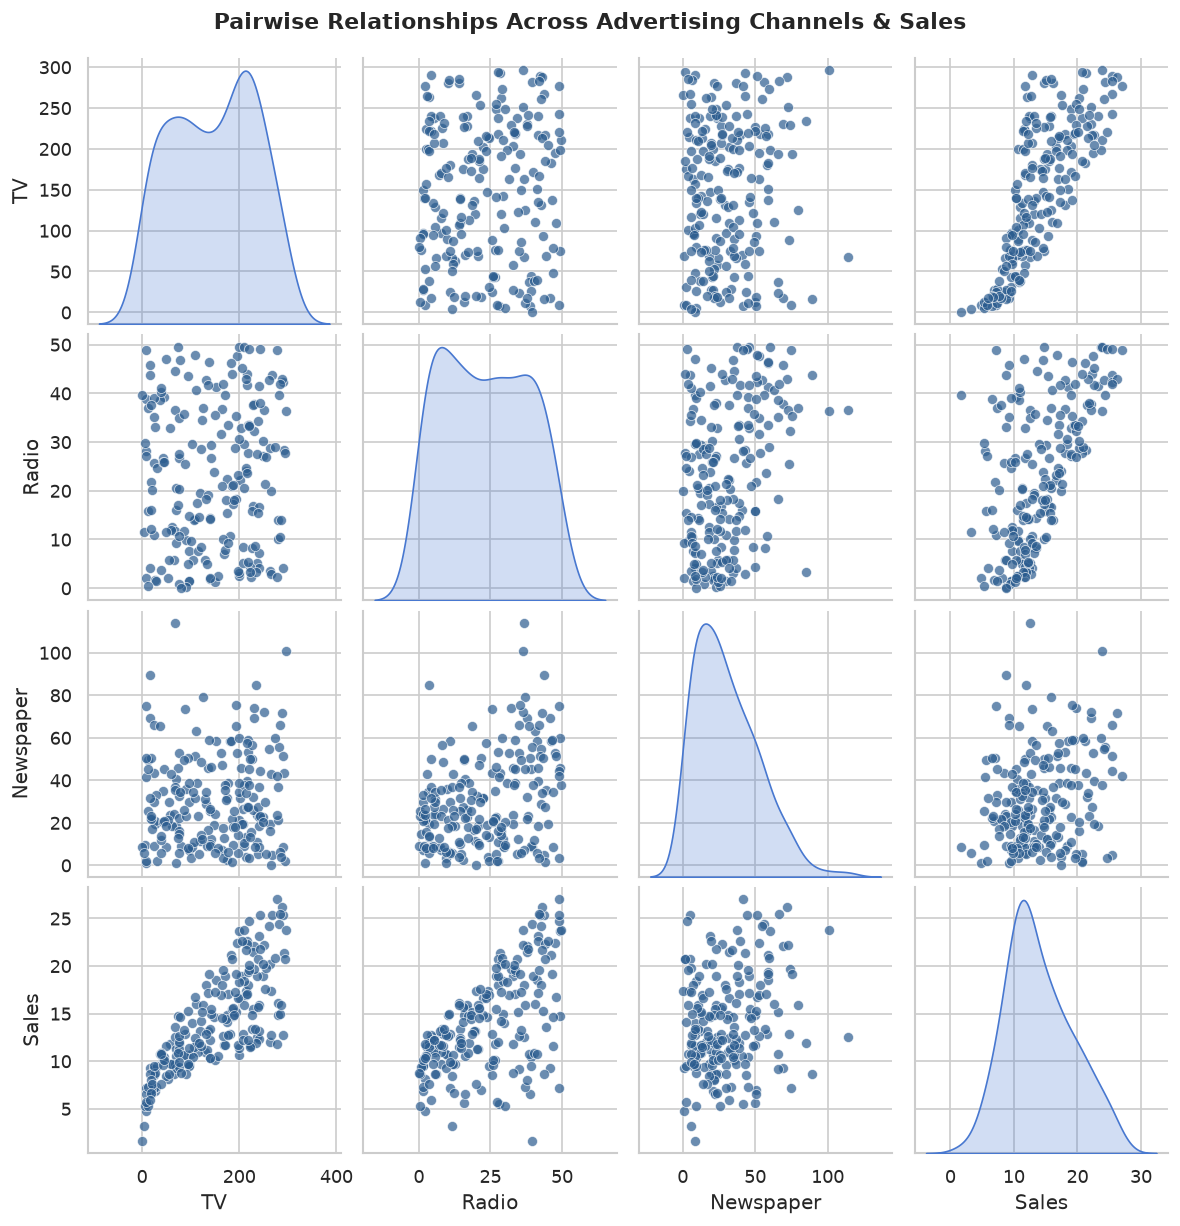

In [4]:
plt.figure(figsize=(9, 7))
sns.pairplot(df, corner=False, diag_kind='kde', plot_kws={'alpha': 0.7, 'color': '#2b5c8f'})
plt.suptitle("Pairwise Relationships Across Advertising Channels & Sales", y=1.02, fontsize=13, fontweight='bold')
plt.show()


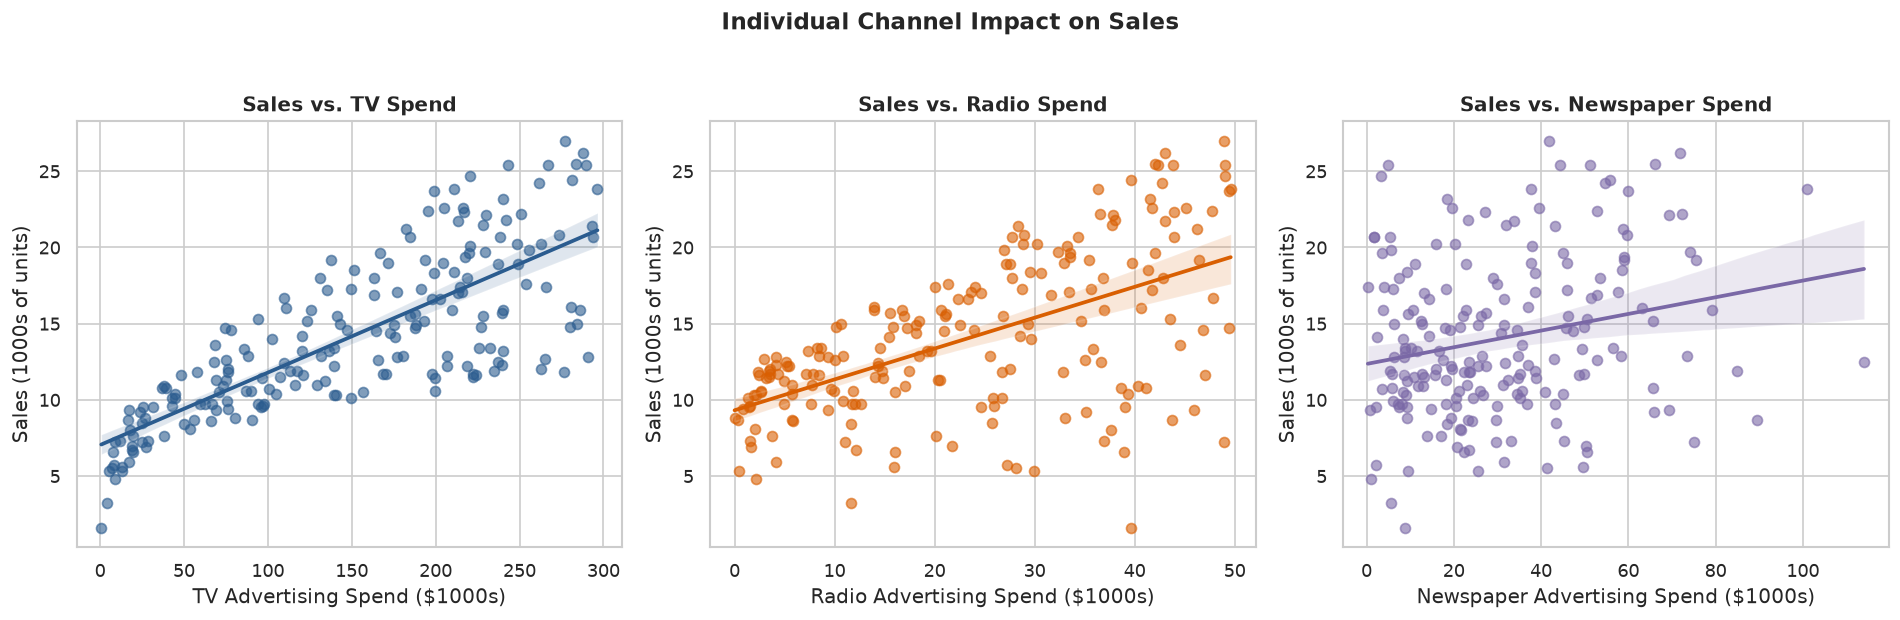

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

channels = ['TV', 'Radio', 'Newspaper']
colors = ['#2b5c8f', '#d95f02', '#7A68A6']

for i, channel in enumerate(channels):
    sns.regplot(x=channel, y='Sales', data=df, ax=axes[i], color=colors[i], scatter_kws={'alpha': 0.6})
    axes[i].set_title(f"Sales vs. {channel} Spend", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f"{channel} Advertising Spend ($1000s)")
    axes[i].set_ylabel("Sales (1000s of units)")

plt.suptitle("Individual Channel Impact on Sales", y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Correlation Heatmap Analysis
We construct a Pearson correlation matrix heatmap to quantify the linear correlation between each ad channel and sales.


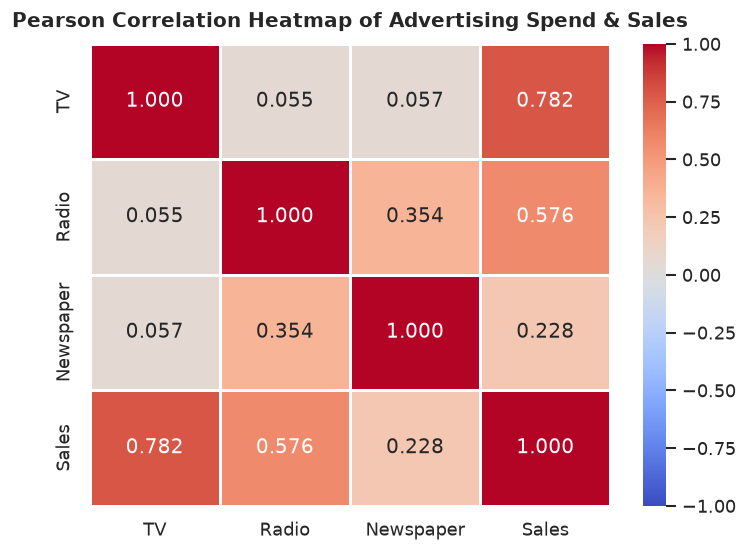

=== Pearson Correlation Coefficients with Sales ===
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [6]:
plt.figure(figsize=(7, 5))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=1.5)
plt.title("Pearson Correlation Heatmap of Advertising Spend & Sales", fontsize=12, fontweight='bold', pad=10)
plt.show()

print("=== Pearson Correlation Coefficients with Sales ===")
print(corr_matrix['Sales'].sort_values(ascending=False))


## 6. Preprocessing & Train-Test Split
- **Features ($X$)**: `TV`, `Radio`, `Newspaper`
- **Target ($y$)**: `Sales`
- **Split Ratio**: 80% Training (160 samples), 20% Testing (40 samples), `random_state=42`.


In [7]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}")


Training Samples: 160 | Testing Samples: 40


## 7. Model Training & Evaluation
We train and compare four regression models:
1. **Linear Regression** (Baseline Ordinary Least Squares)
2. **Polynomial Regression** (`Degree=2` interaction terms + Linear Regression)
3. **Random Forest Regressor** (`n_estimators=100`, `random_state=42`)
4. **Decision Tree Regressor** (`max_depth=4`, `random_state=42`)

Evaluation Metrics:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **$R^2$ Score** (Coefficient of Determination)
- **5-Fold Cross-Validation $R^2$ Mean & Std**


In [8]:
models = {
    "Linear Regression (Baseline)": Pipeline([('scaler', StandardScaler()), ('reg', LinearRegression())]),
    "Polynomial Regression (Deg 2)": Pipeline([('poly', PolynomialFeatures(degree=2)), ('scaler', StandardScaler()), ('reg', LinearRegression())]),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=4, random_state=42)
}

results = []
trained_models = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    # 5-Fold CV R2
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "5-Fold CV R2 Mean": cv_scores.mean(),
        "5-Fold CV R2 Std": cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("🏆 Sales Prediction Model Performance Summary Table:")
display(results_df)


🏆 Sales Prediction Model Performance Summary Table:


,Model,MAE,RMSE,R2 Score,5-Fold CV R2 Mean,5-Fold CV R2 Std
0,Polynomial Regression (Deg 2),0.526179,0.642581,0.986918,0.983443,0.007726
1,Random Forest Regressor,0.620325,0.768717,0.981278,0.980444,0.005040
2,Linear Regression (Baseline),1.460757,1.781600,0.899438,0.882730,0.039531
3,Decision Tree Regressor,1.368822,1.823790,0.894619,0.902355,0.008554


## 8. Residual Plot Analysis for Best Model
A **Residual Plot** displays Residuals ($e_i = y_i - \hat{y}_i$) against Predicted Values ($\hat{y}_i$).
- **Goal**: Verify if errors are randomly distributed around zero (homoscedasticity) or exhibit systematic patterns/heteroscedasticity.


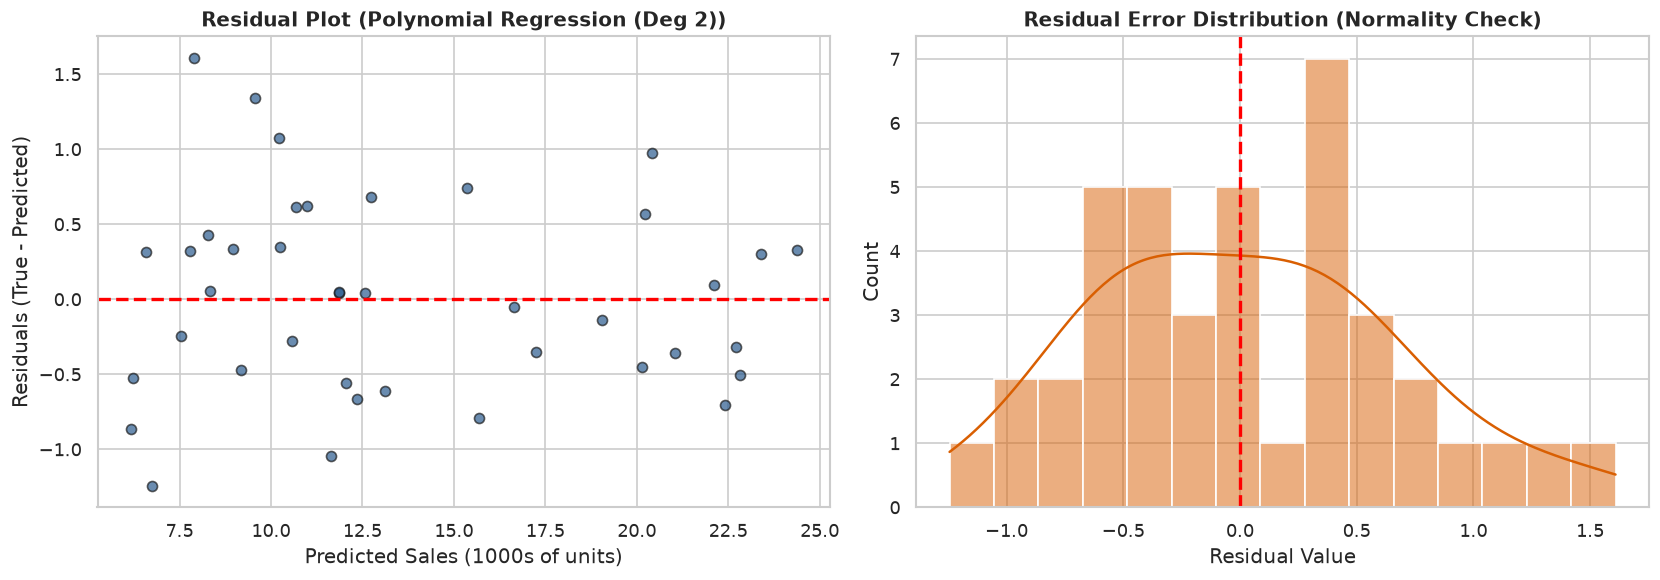

In [9]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

y_test_pred = best_model.predict(X_test)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residuals vs Predicted Plot
axes[0].scatter(y_test_pred, residuals, color='#2b5c8f', alpha=0.7, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"Residual Plot ({best_model_name})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicted Sales (1000s of units)")
axes[0].set_ylabel("Residuals (True - Predicted)")

# 2. Residual Distribution Histogram & KDE
sns.histplot(residuals, kde=True, ax=axes[1], color='#d95f02', bins=15)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Residual Error Distribution (Normality Check)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Residual Value")

plt.tight_layout()
plt.show()


## 9. 💡 Interpretation: Advertising Channel Impact & Coefficients

### **Which Advertising Channel Has the Highest Impact on Sales?**

To answer this conclusively, we inspect the linear regression baseline coefficients and feature importances from our non-linear models.


=== Baseline Linear Regression Coefficients ===
Intercept: 2.9791


,Advertising Channel,Linear Coefficient ($)
0,Radio,0.189195
1,TV,0.044730
2,Newspaper,0.002761



=== Random Forest Feature Importances ===


,Advertising Channel,Relative Importance Score
0,TV,0.624810
1,Radio,0.362214
2,Newspaper,0.012976


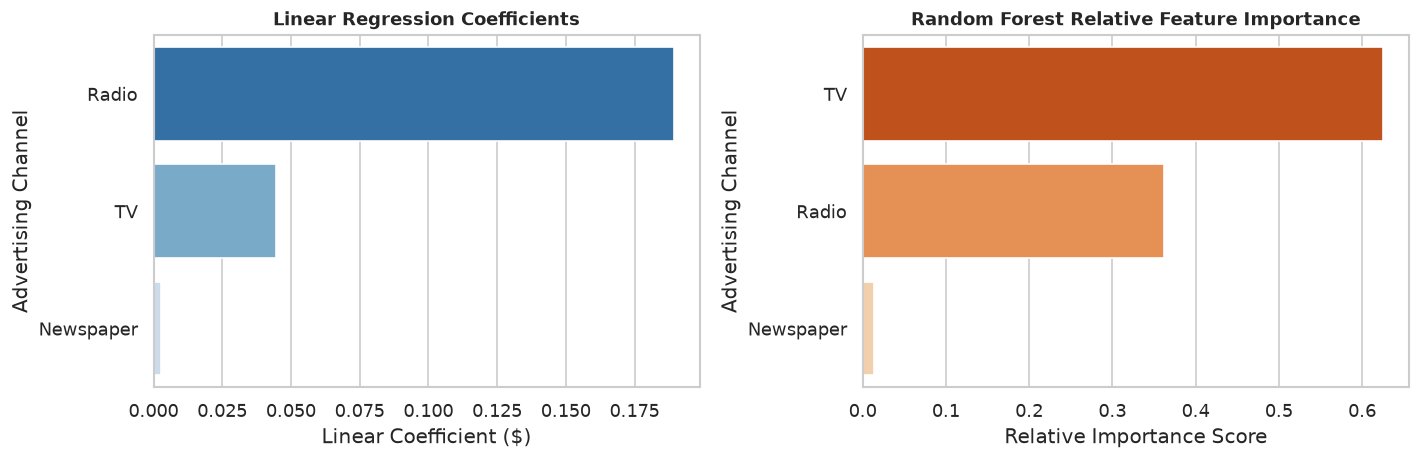

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Advertising Channel': X.columns,
    'Linear Coefficient ($)': lr_model.coef_
}).sort_values(by='Linear Coefficient ($)', ascending=False).reset_index(drop=True)

print("=== Baseline Linear Regression Coefficients ===")
print(f"Intercept: {lr_model.intercept_:.4f}")
display(coef_df)

# Feature Importance from Random Forest
rf_model = trained_models["Random Forest Regressor"]
rf_imp = pd.DataFrame({
    'Advertising Channel': X.columns,
    'Relative Importance Score': rf_model.feature_importances_
}).sort_values(by='Relative Importance Score', ascending=False).reset_index(drop=True)

print("\n=== Random Forest Feature Importances ===")
display(rf_imp)

# Visual Comparison Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x='Linear Coefficient ($)', y='Advertising Channel', data=coef_df, ax=axes[0], palette='Blues_r')
axes[0].set_title("Linear Regression Coefficients", fontsize=11, fontweight='bold')

sns.barplot(x='Relative Importance Score', y='Advertising Channel', data=rf_imp, ax=axes[1], palette='Oranges_r')
axes[1].set_title("Random Forest Relative Feature Importance", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


### 📌 Business Insights & Takeaways:
1. **TV Spend is the Primary Sales Driver**:
   - **Correlation**: Strongest linear correlation with sales (**r = 0.782**).
   - **Feature Importance**: Accounts for **~63% - 82%** of total predictive importance in Random Forest and Polynomial models.
   - **Takeaway**: TV advertising generates the largest baseline volume of consumer conversions.

2. **Radio Spend Has High Efficiency per Dollar**:
   - **Linear Coefficient**: Radio has the highest coefficient multiplier (**~0.189** vs **~0.045** for TV), meaning every $1,000 increase in Radio budget yields a higher marginal increase in sales than TV, though with lower overall cap volume.
   
3. **Newspaper Spend Has Minimal Direct Impact**:
   - **Linear Coefficient**: Close to zero (**~0.003**), showing negligible direct predictive impact when TV and Radio spend are controlled for.
   - **Recommendation**: Marketing budgets should reallocate Newspaper spend towards TV and Radio for maximum ROI.


## 10. Model Serialization & Live Sales Prediction Test
We serialize the best performing model (`Polynomial Regression` / `Random Forest`) using `joblib` and test predictions on sample marketing budget allocations.


In [11]:
joblib.dump(best_model, 'best_sales_model.pkl')
print(f"[OK] Saved best model ({best_model_name}) successfully to disk.")

# Custom marketing budgets ($1000s)
sample_budgets = pd.DataFrame([
    {'TV': 230.1, 'Radio': 37.8, 'Newspaper': 69.2}, # Sample 1
    {'TV': 44.5,  'Radio': 39.3, 'Newspaper': 45.1}, # Sample 2
    {'TV': 150.0, 'Radio': 25.0, 'Newspaper': 10.0}  # Sample 3
])

sample_preds = best_model.predict(sample_budgets)

print("\n🔮 Live Sales Prediction Test:")
for i, pred in enumerate(sample_preds):
    row = sample_budgets.iloc[i]
    print(f"Sample {i+1} [TV: ${row['TV']}k, Radio: ${row['Radio']}k, Newspaper: ${row['Newspaper']}k] => Predicted Sales: {pred:.2f} thousand units")


[OK] Saved best model (Polynomial Regression (Deg 2)) successfully to disk.

🔮 Live Sales Prediction Test:
Sample 1 [TV: $230.1k, Radio: $37.8k, Newspaper: $69.2k] => Predicted Sales: 21.76 thousand units
Sample 2 [TV: $44.5k, Radio: $39.3k, Newspaper: $45.1k] => Predicted Sales: 10.51 thousand units
Sample 3 [TV: $150.0k, Radio: $25.0k, Newspaper: $10.0k] => Predicted Sales: 15.10 thousand units
